## Classification
### Author: Bao Khoi Bui
### UH ID: 2060524

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

data = pd.read_csv('owid_covid_data.csv') 

vaccination_start_date = '2021-01-01'
pre_vaccination = data[data['date'] < vaccination_start_date].copy()
post_vaccination = data[data['date'] >= vaccination_start_date].copy()


### Metrics

In [7]:
def evaluate_model(name, y_test, y_preds):
    accuracy = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds, average='macro')
    recall = recall_score(y_test, y_preds, average='macro')
    macro_f1 = f1_score(y_test, y_preds, average='macro')
    micro_f1 = f1_score(y_test, y_preds, average='micro')

    return [accuracy, precision, recall, macro_f1, micro_f1]

### Model and Prediction

In [10]:
def analysis(data_subset, period):
    data_subset['hospitalization_rate'] = data_subset['hosp_patients'] / data_subset['total_cases']
    data_subset = data_subset.replace([float('inf'), -float('inf')], None).dropna(subset=['hospitalization_rate'])
    data_subset['high_hospitalization'] = (data_subset['hospitalization_rate'] > data_subset['hospitalization_rate'].median()).astype(int)

    selected_features = ['icu_patients', 'hosp_patients', 'new_cases', 'total_deaths']
    X = data_subset[selected_features]
    y = data_subset['high_hospitalization']

    X = X.fillna(X.median())

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    decision_tree = DecisionTreeClassifier(random_state=42)
    random_forest = RandomForestClassifier(random_state=42)

    decision_tree.fit(X_train, y_train)
    random_forest.fit(X_train, y_train)

    dt_preds = decision_tree.predict(X_test)
    rf_preds = random_forest.predict(X_test)

    dt_metrics = evaluate_model(f"Decision Tree ({period})", y_test, dt_preds)
    rf_metrics = evaluate_model(f"Random Forest ({period})", y_test, rf_preds)

    metrics_table = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "Macro-F1", "Micro-F1"],
        f"Decision Tree ({period})": dt_metrics,
        f"Random Forest ({period})": rf_metrics
    })

    print(f"\nMetrics for {period} period:")
    print(metrics_table)

    dt_cm = confusion_matrix(y_test, dt_preds)
    ConfusionMatrixDisplay(confusion_matrix=dt_cm, display_labels=["Low", "High"]).plot(cmap='Blues')
    plt.title(f"Decision Tree ({period})")
    plt.show()

    rf_cm = confusion_matrix(y_test, rf_preds)
    ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=["Low", "High"]).plot(cmap='Greens')
    plt.title(f"Random Forest ({period})")
    plt.show()



Metrics for Pre-Vaccination period:
      Metric  Decision Tree (Pre-Vaccination)  Random Forest (Pre-Vaccination)
0   Accuracy                         0.974903                         0.976190
1  Precision                         0.974774                         0.976016
2     Recall                         0.974990                         0.976379
3   Macro-F1                         0.974872                         0.976165
4   Micro-F1                         0.974903                         0.976190


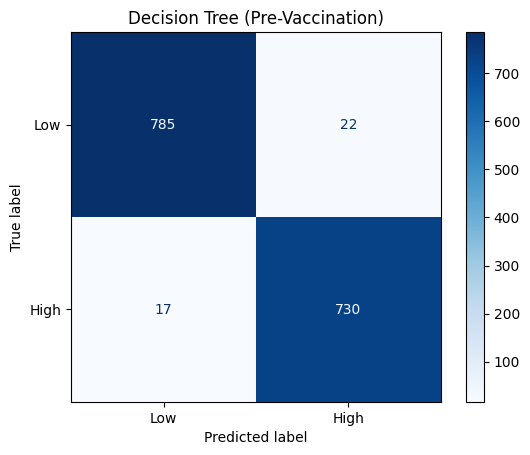

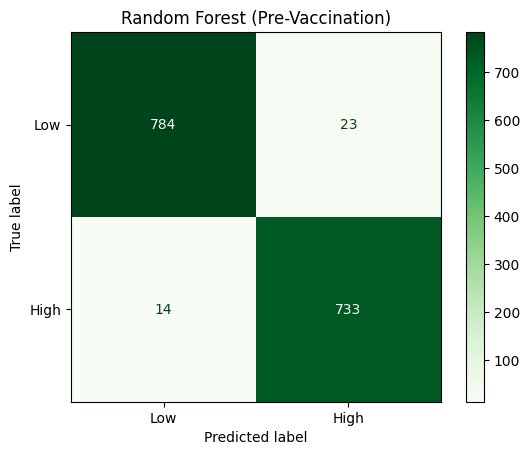


Metrics for Post-Vaccination period:
      Metric  Decision Tree (Post-Vaccination)  \
0   Accuracy                          0.983716   
1  Precision                          0.983701   
2     Recall                          0.983728   
3   Macro-F1                          0.983714   
4   Micro-F1                          0.983716   

   Random Forest (Post-Vaccination)  
0                          0.985707  
1                          0.985685  
2                          0.985731  
3                          0.985704  
4                          0.985707  


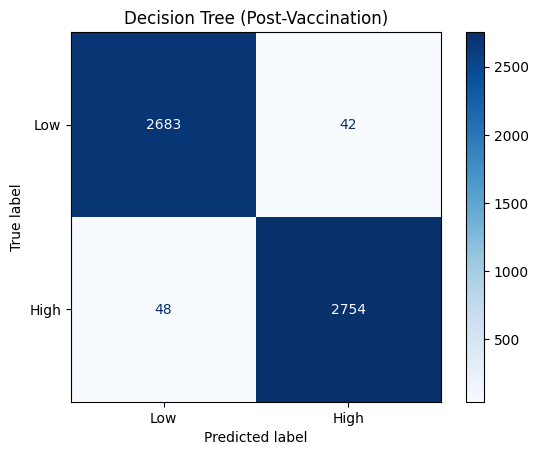

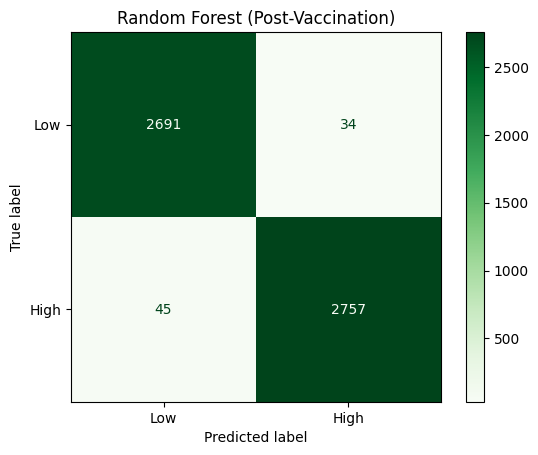

In [11]:
analysis(pre_vaccination, "Pre-Vaccination")
analysis(post_vaccination, "Post-Vaccination")